In [ ]:
from framework import (
    QlearningGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In this notebook I investigate the evolution of the Q-values of the Q-learning algorithms playing each other in an auction environment(FPA and SPA). I do this to understand the learning procedure.

In [ ]:
bidder1 = QlearningGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = QlearningGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)

simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

FPA_history = simulation.run()

Convergence detected after 70056 rounds.
Bidder Agent1 converged to bid 0.15.
Bidder Agent2 converged to bid 0.15.


In [ ]:
bidder1 = QlearningGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)
bidder2 = QlearningGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, delta=0)

simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

SPA_history = simulation.run()

Convergence detected after 308056 rounds.
Bidder Agent1 converged to bid 0.95.
Bidder Agent2 converged to bid 0.95.


In [8]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

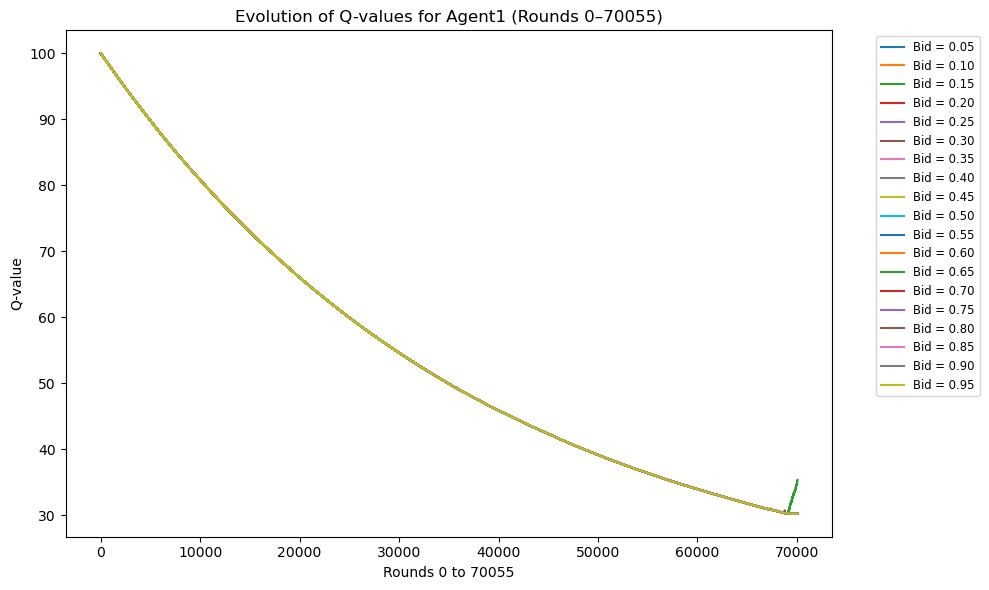

In [10]:
def plot_q_evolution_range(history, bidder_name, start_round, end_round):
    """
    Plot Q-value trajectories for all bids of `bidder_name` between
    start_round and end_round (inclusive).
    
    Parameters
    ----------
    history : list
        Auction history, where each element ends with q_snapshot: {bidder_name: q_values}.
    bidder_name : str
        Name of the bidder to plot.
    start_round : int
        Index of the starting round (0-based).
    end_round : int
        Index of the ending round (0-based, inclusive).
    """
    n = len(history)
    if n == 0:
        raise ValueError("History is empty.")
    if start_round < 0 or end_round >= n:
        raise ValueError(f"start_round and end_round must be within [0, {n-1}].")
    if end_round < start_round:
        raise ValueError("end_round must be greater than or equal to start_round.")

    # Slice history for the given range
    hist_slice = history[start_round:end_round+1]

    # Bid grid (same as in your environment)
    bid_options = np.array([i*0.05 for i in range(1, 20)])
    num_bids = len(bid_options)

    # Plot trajectories
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_slice, bidder_name, bid_idx)
        plt.plot(range(start_round, end_round+1), q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds {start_round} to {end_round}")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name} (Rounds {start_round}–{end_round})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    plt.show()

plot_q_evolution_range(FPA_history, "Agent1", 0, 70055)

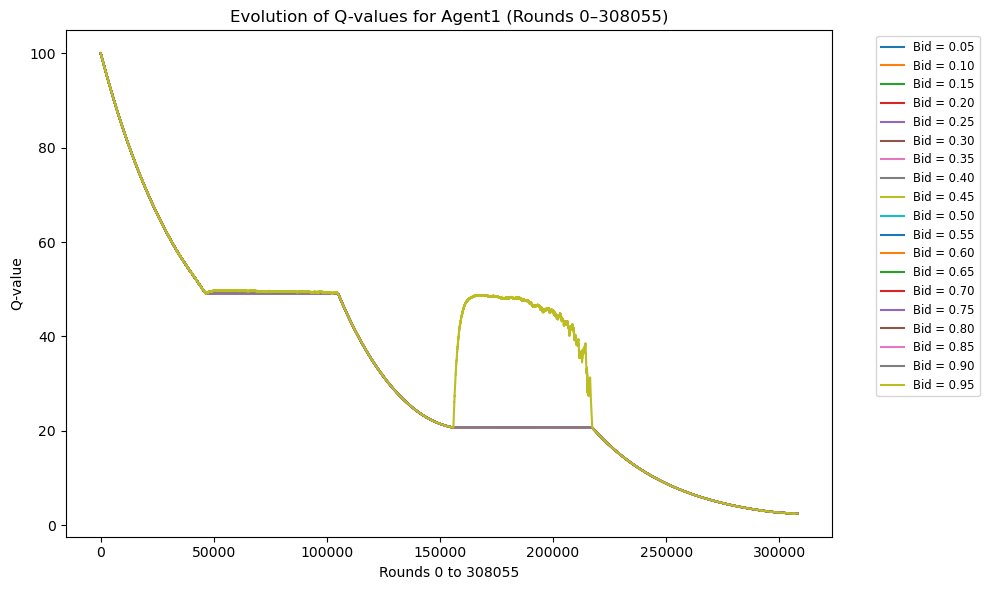

In [17]:
plot_q_evolution_range(SPA_history, "Agent1", 0, 308055)

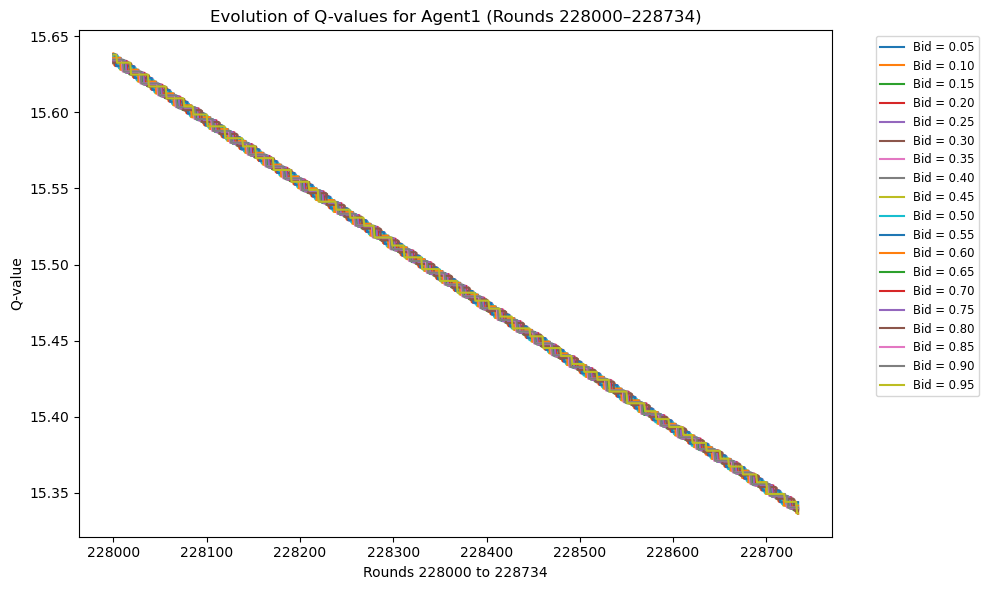

In [18]:
plot_q_evolution_range(SPA_history, "Agent1", 228000, 228734)

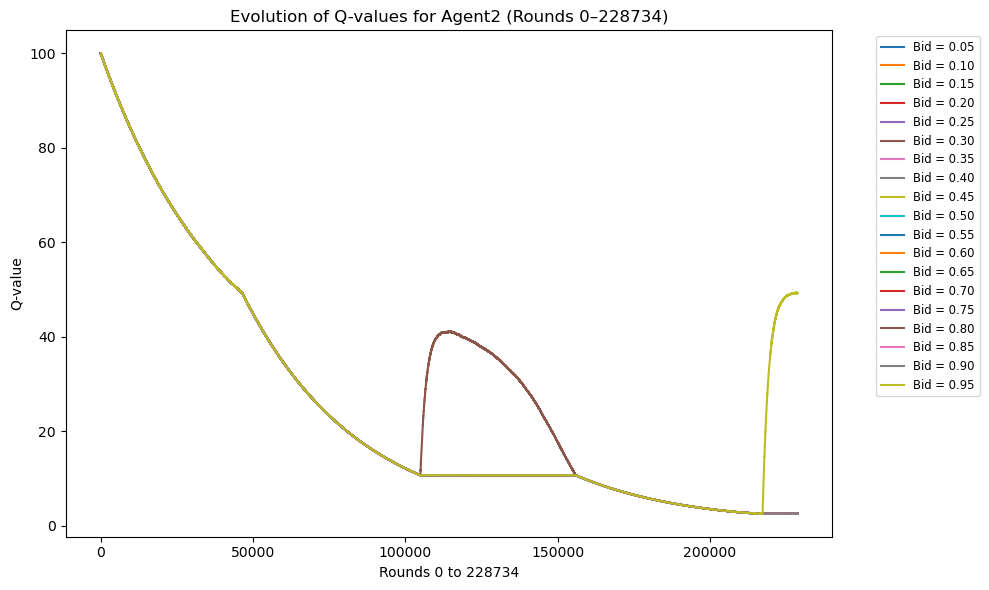

In [19]:
plot_q_evolution_range(SPA_history, "Agent2", 0, 228734)

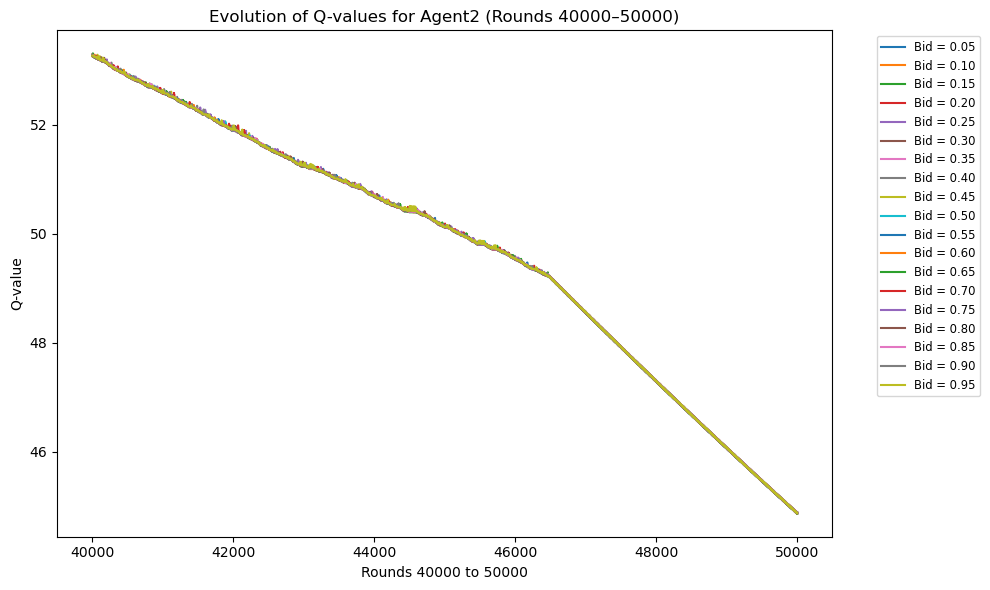

In [20]:
plot_q_evolution_range(SPA_history, "Agent2", 40000, 50000)

In [35]:
import numpy as np

def moving_average(data, window_size):
    return [np.mean(data[i:i+window_size]) for i in range(0, len(data) - window_size + 1)]

# Extract raw winning bids
winning_bids_fpa = [entry[2] for entry in FPA_history]
winning_bids_spa = [entry[2] for entry in SPA_history]

# Compute moving averages with window of 10
ma_fpa = moving_average(winning_bids_fpa, window_size=1000)
ma_spa = moving_average(winning_bids_spa, window_size=1000)

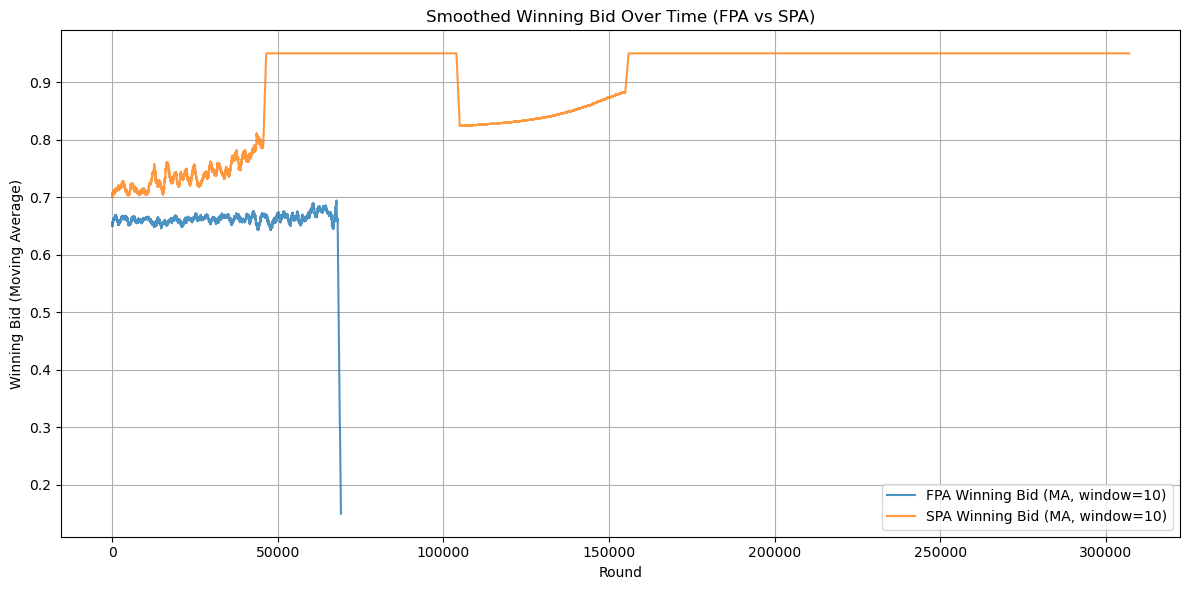

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(ma_fpa, label="FPA Winning Bid (MA, window=10)", alpha=0.8)
plt.plot(ma_spa, label="SPA Winning Bid (MA, window=10)", alpha=0.8)
plt.xlabel("Round")
plt.ylabel("Winning Bid (Moving Average)")
plt.title("Smoothed Winning Bid Over Time (FPA vs SPA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Winning_bid_moving_average_1000.pdf")
plt.show()

In [24]:
FPA_baseline = pd.read_csv("Results_FPA/Initial results/FPA_auction_summary_results.csv")
SPA_baseline = pd.read_csv("Results_FPA/Initial results/SPA_auction_summary_results.csv")

In [25]:
import seaborn as sns

def plot_bid_heatmap(df, title=None):
    bid_options = [round(i * 0.05, 2) for i in range(1, 20)]  # [0.05, 0.10, ..., 0.95]

    heatmap_matrix = pd.DataFrame(0, index=bid_options, columns=bid_options)

    for b1, b2 in zip(df["converged_bid_Agent1"], df["converged_bid_Agent2"]):
        heatmap_matrix.at[round(b2, 2), round(b1, 2)] += 1  # Rows: Agent2, Cols: Agent1

    heatmap_matrix = heatmap_matrix / heatmap_matrix.values.sum()

    heatmap_matrix = heatmap_matrix.sort_index(ascending=False)

    plt.figure(figsize=(10, 7))
    sns.heatmap(heatmap_matrix, cmap="YlGnBu", annot=True, fmt=".2f",
            xticklabels=bid_options, yticklabels=heatmap_matrix.index)
    plt.xlabel("Agent 1 Converged Bid")
    plt.ylabel("Agent 2 Converged Bid")
    plt.tight_layout()
    plt.savefig(f"{title}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

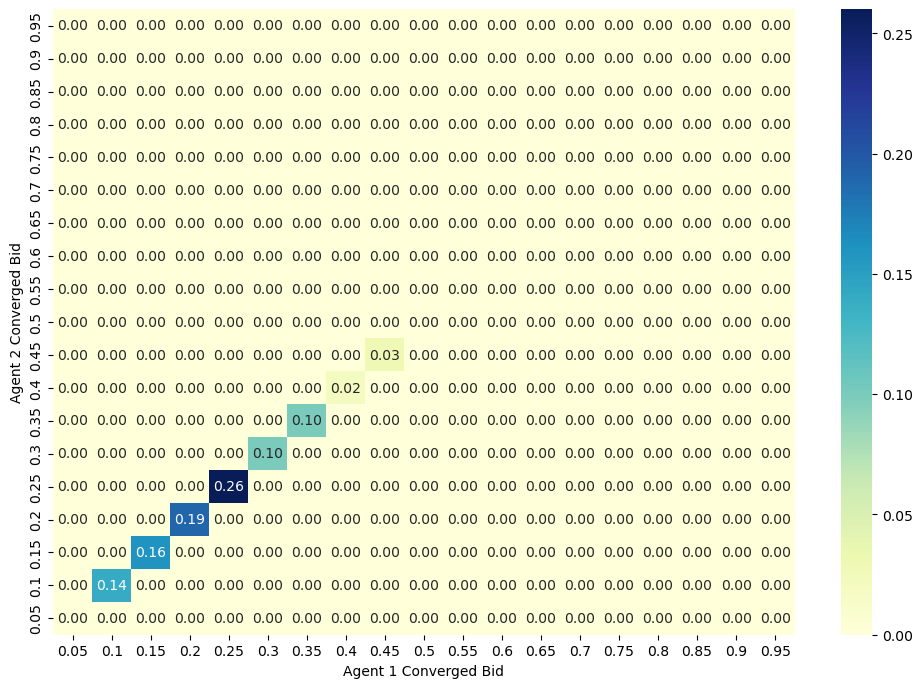

In [26]:
plot_bid_heatmap(FPA_baseline, "baseline_FPA_matrix")

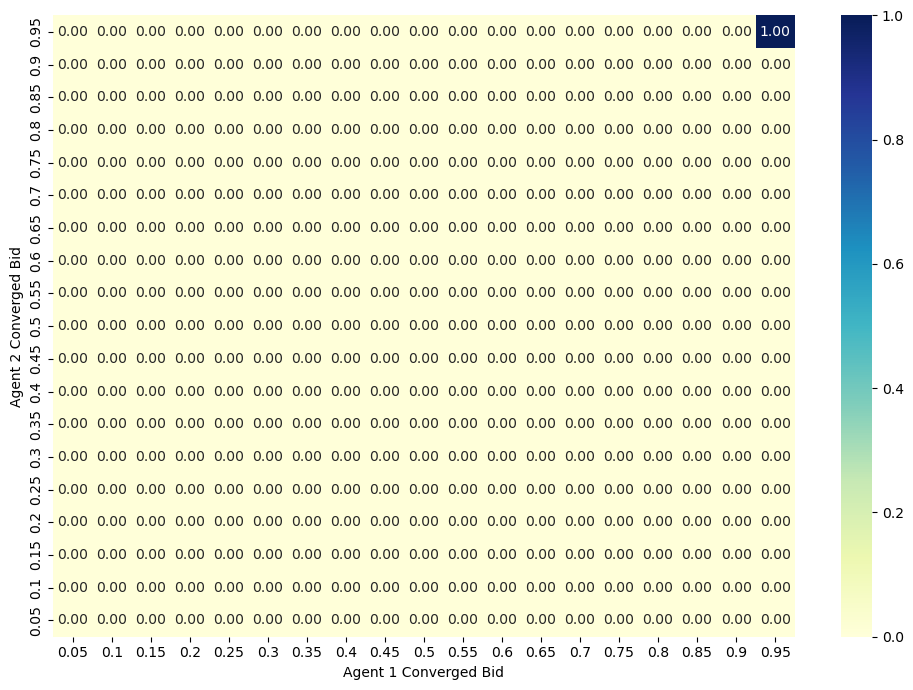

In [27]:
plot_bid_heatmap(SPA_baseline, "baseline_SPA_matrix")

In [32]:
print("The mean bid converged to in the FPA is: ",FPA_baseline["converged_bid_Agent1"].mean())
print("The mean bid converged to in the SPA is: ",SPA_baseline["converged_bid_Agent1"].mean())

The mean bid converged to in the FPA is:  0.22750000000000004
The mean bid converged to in the SPA is:  0.95
